### Puxar base de dados

In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

tabela = pd.read_csv(r"C:\Users\TW-5818\OneDrive\Desktop\Codigos\exportacoes_franca.csv")

display(tabela)

,Year,Month,Country,City,SH4 Code,SH4 Description,SH2 Code,SH2 Description,Economic Block,US$ FOB,Net Weight
0,2016,1,France,Águas Mornas - SC,303,"Fish, frozen, excluding fish fillets and other...",3,"Fish and crustaceans, molluscs and other aquat...",Europe,79360,14150
1,2016,1,France,Águas Mornas - SC,303,"Fish, frozen, excluding fish fillets and other...",3,"Fish and crustaceans, molluscs and other aquat...",European Union (EU),79360,14150
2,2016,1,France,Águas Mornas - SC,304,Fish fillets and other fish meat (whether or n...,3,"Fish and crustaceans, molluscs and other aquat...",Europe,69412,9385
3,2016,1,France,Águas Mornas - SC,304,Fish fillets and other fish meat (whether or n...,3,"Fish and crustaceans, molluscs and other aquat...",European Union (EU),69412,9385
4,2016,1,France,Alfenas - MG,901,"Coffee, whether or not roasted or decaffeinate...",9,"Coffee, tea, maté and spices",Europe,180914,57600
...,...,...,...,...,...,...,...,...,...,...,...
142355,2020,12,France,Vinhedo - SP,8424,Mechanical appliances (whether or not hand-ope...,84,"Nuclear reactors, boilers, machinery and mecha...",European Union (EU),2316,4
142356,2020,12,France,Vitória de Santo Antão - PE,714,"Manioc, arrowroot, salep, Jerusalem artichokes...",7,Edible vegetables and certain roots and tubers,Europe,27060,26400
142357,2020,12,France,Vitória de Santo Antão - PE,714,"Manioc, arrowroot, salep, Jerusalem artichokes...",7,Edible vegetables and certain roots and tubers,European Union (EU),27060,26400
142358,2020,12,France,Xapuri - AC,4409,Wood (including strips and friezes for parquet...,44,Wood and articles of wood; wood charcoal,Europe,31111,23045


### Informações Gerais

Quantas linhas têm a tabela? Existe algum valor vazio que deveria ser tratado?

In [100]:
tabela.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142360 entries, 0 to 142359
Data columns (total 11 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   Year             142360 non-null  int64 
 1   Month            142360 non-null  int64 
 2   Country          142360 non-null  object
 3   City             142360 non-null  object
 4   SH4 Code         142360 non-null  int64 
 5   SH4 Description  142360 non-null  object
 6   SH2 Code         142360 non-null  int64 
 7   SH2 Description  142360 non-null  object
 8   Economic Block   142360 non-null  object
 9   US$ FOB          142360 non-null  int64 
 10  Net Weight       142360 non-null  int64 
dtypes: int64(6), object(5)
memory usage: 11.9+ MB


### Como foi a evolução das exportações para a frança ao longo dos anos?

Crie uma tabela com os anos de 2016, 2017, 2018, 2019 e 2020 e o valor US$ de exportações

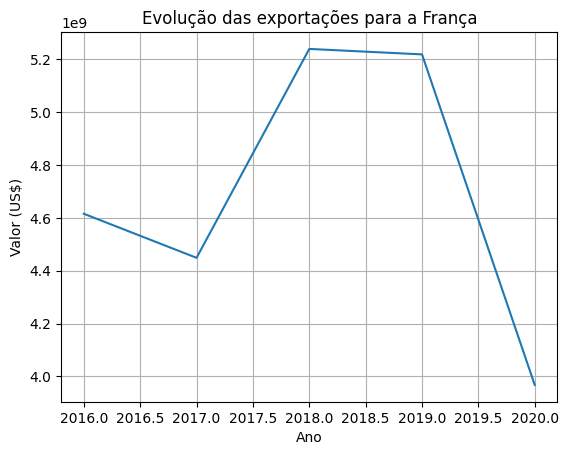

,Year,US$ FOB
0,2016,"U$4,615,500,082"
1,2017,"U$4,448,705,456"
2,2018,"U$5,239,424,416"
3,2019,"U$5,218,723,612"
4,2020,"U$3,967,594,810"


In [101]:
tabela_anos_exportacao = tabela[['Year', 'US$ FOB']].groupby('Year').sum()
tabela_anos_exportacao = tabela_anos_exportacao.reset_index()

plt.figure()
plt.plot(tabela_anos_exportacao['Year'], tabela_anos_exportacao['US$ FOB'])
plt.title('Evolução das exportações para a França')
plt.xlabel('Ano')
plt.ylabel('Valor (US$)')
plt.grid()
plt.savefig('evolucao_todos_anos.png', bbox_inches='tight')
plt.show()

def formatar(valor):
    valor_formatado = f'U${valor:,}'
    return valor_formatado

tabela_anos_exportacao['US$ FOB'] = tabela_anos_exportacao['US$ FOB'].apply(formatar)

display(tabela_anos_exportacao)

### Quais os produtos mais exportados ao longo de todo o período?

Queremos saber os produtos com maior valor US$ de exportação

<Figure size 640x480 with 0 Axes>

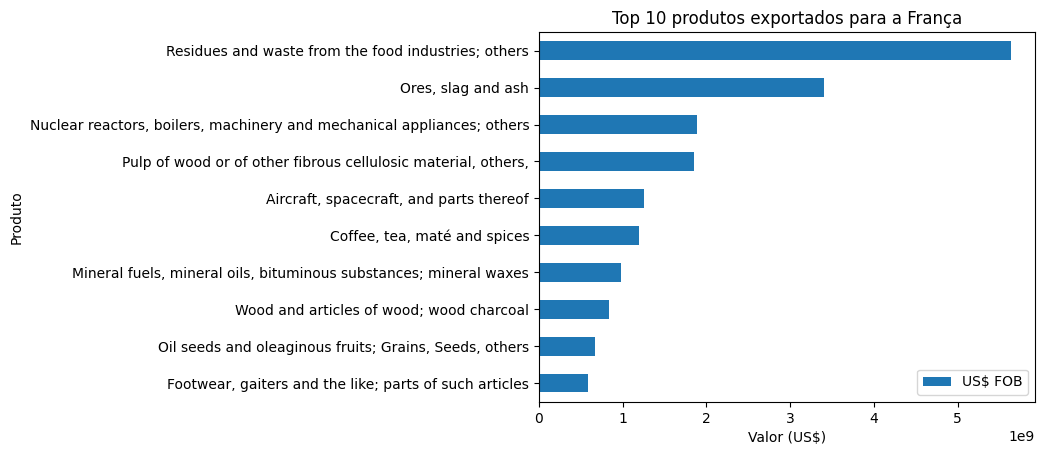

,US$ FOB
SH2 Description,
Residues and waste from the food industries; others,"U$5,641,498,484"
"Ores, slag and ash","U$3,404,353,274"
"Nuclear reactors, boilers, machinery and mechanical appliances; others","U$1,889,781,694"
"Pulp of wood or of other fibrous cellulosic material, others,","U$1,855,424,642"
"Aircraft, spacecraft, and parts thereof","U$1,253,007,710"
...,...
"Umbrellas, sun umbrellas, walking-sticks, seat-sticks, whips, riding-crops, others","U$18,872"
Cork and articles of cork,"U$10,974"
"Wool, fine or coarse animal hair; horsehair yarn and woven fabric","U$2,540"


In [102]:
produtos_mais_exportados = tabela[['SH2 Description', 'US$ FOB']].groupby('SH2 Description').sum()
produtos_mais_exportados = produtos_mais_exportados.sort_values(by='US$ FOB', ascending=False)

plt.figure()
produtos_mais_exportados.head(10).plot(kind='barh')
plt.title('Top 10 produtos exportados para a França')
plt.xlabel('Valor (US$)')
plt.ylabel('Produto')
plt.gca().invert_yaxis()
plt.savefig('produtos_mais_exportados', bbox_inches='tight')
plt.show()

produtos_mais_exportados['US$ FOB'] = produtos_mais_exportados['US$ FOB'].apply(formatar)

display(produtos_mais_exportados)

### Em 2020 qual cidade mais exportou para a França?
Em valores US$

<Figure size 640x480 with 0 Axes>

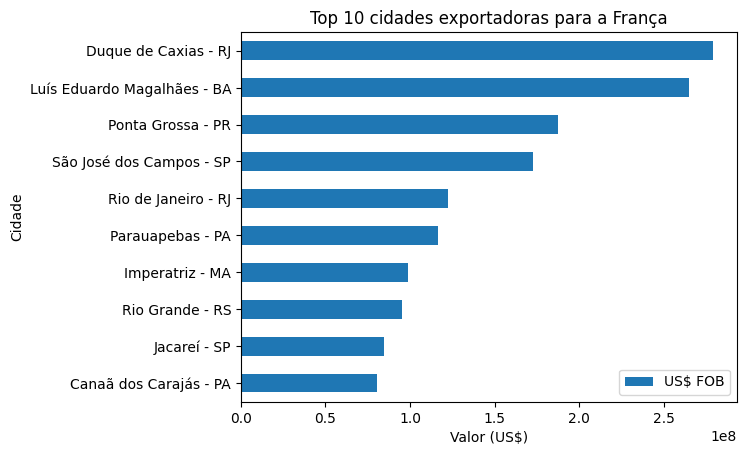

,US$ FOB
City,
Duque de Caxias - RJ,"U$279,405,596"
Luís Eduardo Magalhães - BA,"U$265,328,132"
Ponta Grossa - PR,"U$187,777,016"
São José dos Campos - SP,"U$172,939,276"
Rio de Janeiro - RJ,"U$122,522,214"
...,...
Não-Me-Toque - RS,U$42
Cubatão - SP,U$40
Holambra - SP,U$10


In [103]:
tabela2020 = tabela.loc[tabela['Year'] == 2020, :]
cidade_mais_exportou = tabela2020[['City', 'US$ FOB']].groupby('City').sum()
cidade_mais_exportou = cidade_mais_exportou.sort_values(by='US$ FOB', ascending=False)

plt.figure()
cidade_mais_exportou.head(10).plot(kind='barh')
plt.title('Top 10 cidades exportadoras para a França')
plt.xlabel('Valor (US$)')
plt.ylabel('Cidade')
plt.gca().invert_yaxis()
plt.savefig('cidade_mais_exportou.png', bbox_inches='tight')
plt.show()

cidade_mais_exportou['US$ FOB'] = cidade_mais_exportou['US$ FOB'].apply(formatar)

display(cidade_mais_exportou)

### Quais os produtos mais exportados (em US$) que a maior cidade (em exportação em 2020) exportou?

<Figure size 640x480 with 0 Axes>

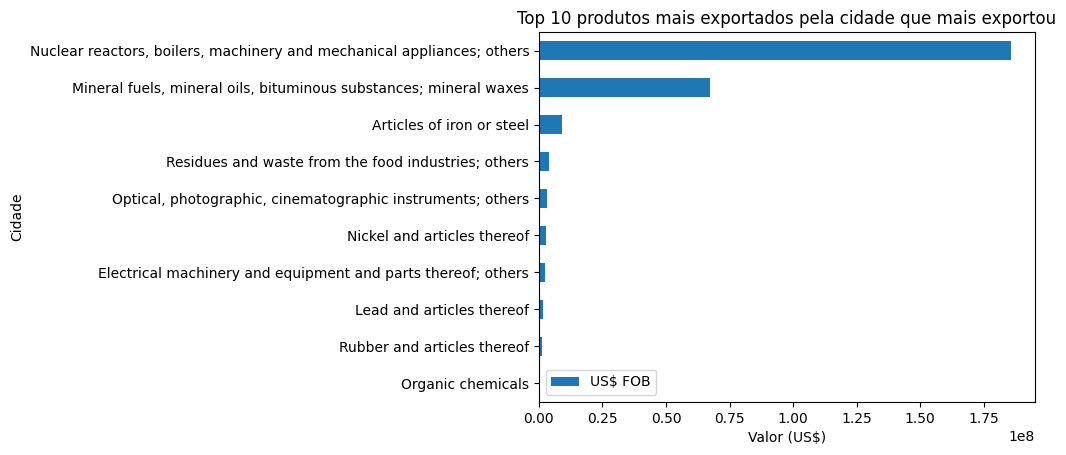

,US$ FOB
SH2 Description,
"Nuclear reactors, boilers, machinery and mechanical appliances; others","U$185,816,982"
"Mineral fuels, mineral oils, bituminous substances; mineral waxes","U$67,355,688"
Articles of iron or steel,"U$9,118,714"
Residues and waste from the food industries; others,"U$4,014,274"
"Optical, photographic, cinematographic instruments; others","U$3,013,092"
Nickel and articles thereof,"U$2,951,286"
Electrical machinery and equipment and parts thereof; others,"U$2,595,048"
Lead and articles thereof,"U$1,660,180"
Rubber and articles thereof,"U$1,379,296"


In [104]:
cidade = cidade_mais_exportou.index[0]

duque_caxias = tabela2020.loc[tabela2020['City']==cidade, :]
produtos_mais_vendidos = duque_caxias[['US$ FOB', 'SH2 Description']].groupby('SH2 Description').sum()
produtos_mais_vendidos = produtos_mais_vendidos.sort_values(by='US$ FOB', ascending=False)

plt.figure()
produtos_mais_vendidos.head(10).plot(kind='barh')
plt.title('Top 10 produtos mais exportados pela cidade que mais exportou')
plt.xlabel('Valor (US$)')
plt.ylabel('Cidade')
plt.gca().invert_yaxis()
plt.savefig('produto_mais_exportado_pela_cidade.png', bbox_inches='tight')
plt.show()

produtos_mais_vendidos['US$ FOB'] = produtos_mais_vendidos['US$ FOB'].apply(formatar)
display(produtos_mais_vendidos)

### Qual a participação (%) dos principais produtos?

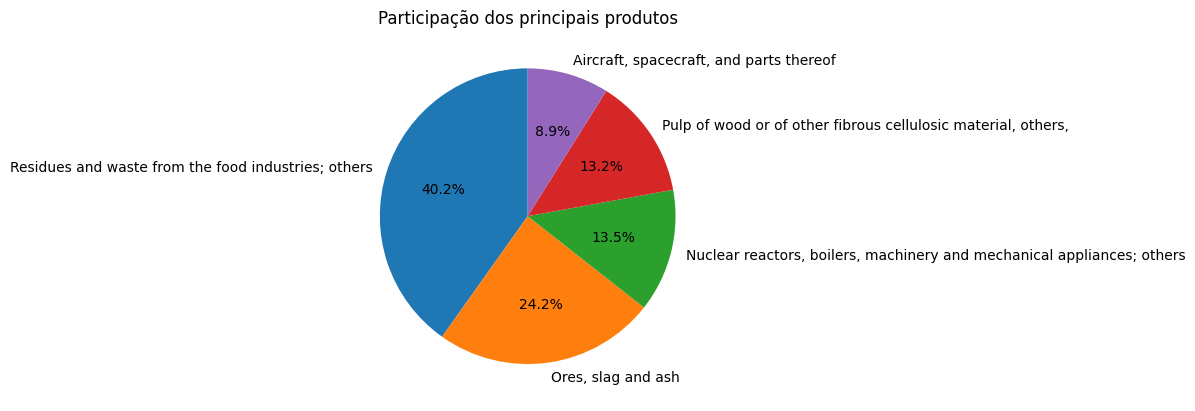

,Porcentagem
SH2 Description,
Residues and waste from the food industries; others,40.17%
"Ores, slag and ash",24.24%
"Nuclear reactors, boilers, machinery and mechanical appliances; others",13.46%
"Pulp of wood or of other fibrous cellulosic material, others,",13.21%
"Aircraft, spacecraft, and parts thereof",8.92%


In [105]:
participacao = tabela.groupby('SH2 Description')['US$ FOB'].sum()
participacao = participacao.sort_values(ascending=False).head(5)
participacao = participacao / participacao.sum()

plt.figure()
participacao.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Participação dos principais produtos')
plt.ylabel('')
plt.savefig('participacao_dos_principais_produtos.png', bbox_inches='tight')
plt.show()

def porcetagem(valor):
    valor_formatado = f'{valor:.2%}'
    return valor_formatado

participacao = pd.DataFrame(participacao)
participacao = participacao.rename(columns={'US$ FOB': 'Porcentagem'})
participacao['Porcentagem'] = participacao['Porcentagem'].apply(porcetagem)
display(participacao)

### Qual a evolução de um produto específico?

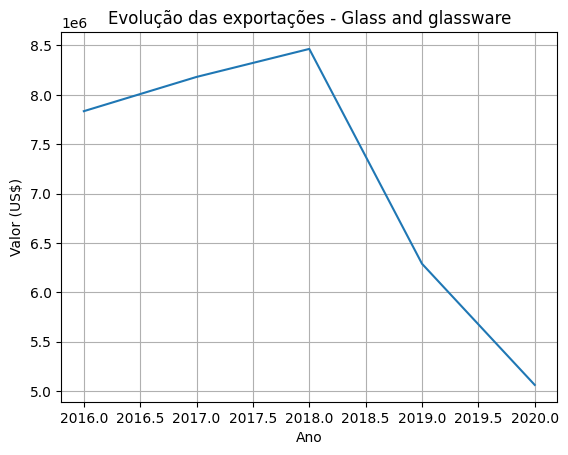

In [106]:
produto = 'Glass and glassware'

filtro_produto = tabela[tabela['SH2 Description'] == produto]

evolucao_produto = (filtro_produto.groupby('Year')['US$ FOB'].sum().reset_index())

plt.figure()
plt.plot(evolucao_produto['Year'], evolucao_produto['US$ FOB'])
plt.title(f'Evolução das exportações - {produto}')
plt.xlabel('Ano')
plt.ylabel('Valor (US$)')
plt.grid()
plt.savefig('evolucao_especifica_produto.png', bbox_inches='tight')
plt.show()